# PARTE 1: Comprensión e interpretación de datos

## Objetivo del análisis
El objetivo es explorar y comunicar hallazzgos clave de las ventas de la empresa retail, para apoyar decisiones comerciales. Se busca entender tendencias temporales, categorías más rentables, patrones por región y diferencias según tipo de cliente.

## Contexto del negocio
La gerencia comercial necesita información clara y visual para responder preguntas estratégicas:
- ¿Cómo evolucionan las ventas en el tiempo?
- ¿Qué categorías y productos generan más ingresos?
- ¿Existen diferencias relevantes por región o tipo de cliente?
- ¿Qué hallazgos pueden guiar decisiones de marketing, inventario y expansión?

## Clasificación de variables
| Variable | Tipo de dato | Naturaleza |
|-----------|-----------|-----------|
| fecha_venta | Cualitativa ordinal | Continua |
| categoria_producto | Cualitativa nominal | Discreta |
| producto | Cualitativa nominal | Discreta |
| region | Cualitativa nominal | Discreta |
| tipo_cliente | Cualitativa nominal | Discreta |
| unidades__vendidas | Cuantitativa entera | Discreta |
| precio_unitario | Cuantitativa real | Continua |
| monto_total | Cuantitativa real | Continua |

## Posibles preguntas del negocio
- ¿Cómo evolucionan las ventas a lo largo del tiempo?
- ¿Qué categorías de producto generan mayores ingresos?
- ¿Existe relación entre unidades vendidas y monto total?
- ¿Qué regiones y tipos de clientes aportan más ingresos?
- ¿Qué meses o segmentos requieren estrategias de mejora?

# PARTE 2: Selección y construcción de visualizaciones

1. **Evolución temporal**
Gráfico: Línea de tiempo con ventas totales por mes.
- Justificación: Las líneas permiten ver tendencias y estacionalidad.
- Información: Identifica picos de ventas y caidas.

2. **Comparativo por categoría**
Gráfico: Barras horizontales con ingresos por categoria.
- Justificación: Las barras facilitan comparar magnitudes entre categorías.
- Información: Muestra qué categorías son más rentables y dónde enfocar promociones.

3. **Relación entre 2 variables**
Gráfico: Dispersión entre unidades vendidas y monto_total.
- Justifficación: Permite ver si mayores volúmenes implican mayores ingresos.
- Información: Detecta productos de alto margen vs productos de bajo margen.

4. **Segmentación de clientes/regiones**
Gráfico: Mapa de calor con ingresos por región y tipo de cliente.
- Justificación: El color facilita identificar patrones geográficos y de segmento.
- Información: Revela regiones fuertes en mayoristas vs minoristas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carga de datos
df = pd.read_csv("dataset_ventas_modulo_7.csv")
df.head()

,fecha_venta,categoria_producto,producto,region,tipo_cliente,unidades_vendidas,precio_unitario,monto_total
0,2023-03-26,Hogar,Mesa,Sur,Mayorista,12,346928,4163136
1,2023-01-02,Vestuario,Chaqueta,Norte,Minorista,5,16521,82605
2,2023-04-21,Vestuario,Polera,Centro,Mayorista,1,400189,400189
3,2023-08-12,Tecnologia,Smartphone,Norte,Minorista,19,401875,7635625
4,2023-08-05,Tecnologia,Tablet,Norte,Mayorista,3,284220,852660


In [7]:
# Configuración estética
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

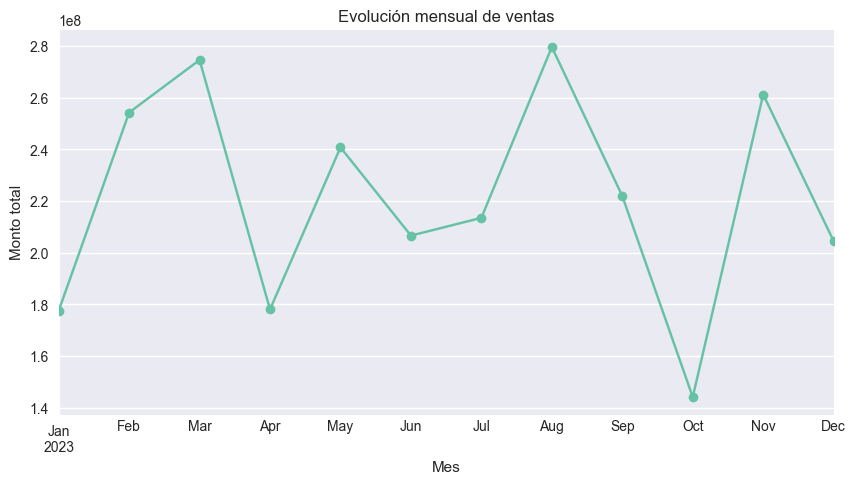

In [8]:
# Evolución temporal de ventas
df['fecha_venta'] = pd.to_datetime(df['fecha_venta'])
ventas_tiempo = df.groupby(df['fecha_venta'].dt.to_period("M"))['monto_total'].sum()

ventas_tiempo.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Evolución mensual de ventas")
plt.xlabel("Mes")
plt.ylabel("Monto total")
plt.show()

**Interpretación:**
Este gráfico muestra la evolución de las ventas mes a mes durante el año. Se observan picos en marzo y agosto, mientras que abril y octubre presentan caídas significativas. Esto sugiere un patrón estacional influenciado por campañas o eventos específicos.

**Justificación del gráfico:**
La línea temporal es adecuada porque permite visualizar tendencias y variaciones a lo largo del tiempo, facilitando la identificación de estacionalidad.

**Hallazgo clave:**
La empresa debería anticipar inventario y campañas en los meses de mayor demanda, y analizar las causas de las caídas para mitigarlas.

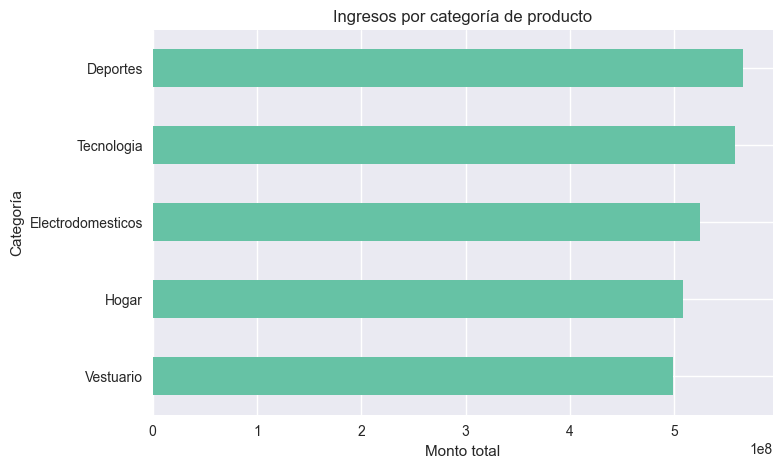

In [9]:
# Comparativa por categoría
ventas_categoria = df.groupby("categoria_producto")['monto_total'].sum().sort_values()

ventas_categoria.plot(kind="barh", figsize=(8,5))
plt.title("Ingresos por categoría de producto")
plt.xlabel("Monto total")
plt.ylabel("Categoría")
plt.show()

**Interpretación:**
Las categorías muestran ingresos relativamente similares, aunque Tecnología y Deportes destacan levemente sobre las demás. Esto indica que no hay una categoría dominante absoluta, pero sí algunas con mayor potencial.

**Justificación del gráfico:**
El gráfico de barras horizontales facilita la comparación directa entre categorías, mostrando claramente cuáles generan más ingresos.

**Hallazgo clave:**
La gerencia puede reforzar las categorías líderes con campañas de marketing y evaluar estrategias para potenciar las de menor rendimiento.


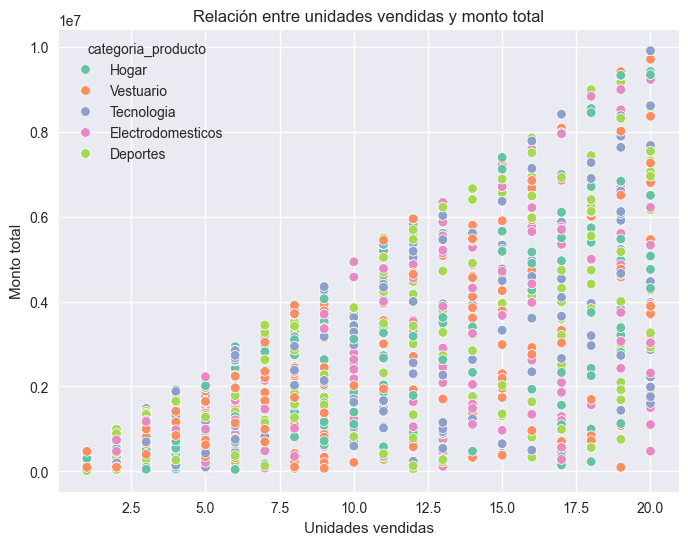

In [10]:
# Relación entre unidades vendidas y monto total
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="unidades_vendidas", y="monto_total", hue="categoria_producto")
plt.title("Relación entre unidades vendidas y monto total")
plt.xlabel("Unidades vendidas")
plt.ylabel("Monto total")
plt.show()

**Interpretación:**
Se observa una tendencia positiva: a mayor número de unidades vendidas, mayor monto total. Sin embargo, algunos productos generan altos ingresos con pocas unidades, lo que refleja un precio unitario elevado.

**Justificación del gráfico:**
El scatter plot es ideal para mostrar la relación entre dos variables cuantitativas, permitiendo identificar patrones y productos de alto margen.

**Hallazgo clave:**
La empresa puede diferenciar su estrategia: impulsar productos de alto volumen para mayoristas y destacar productos de alto margen para minoristas.


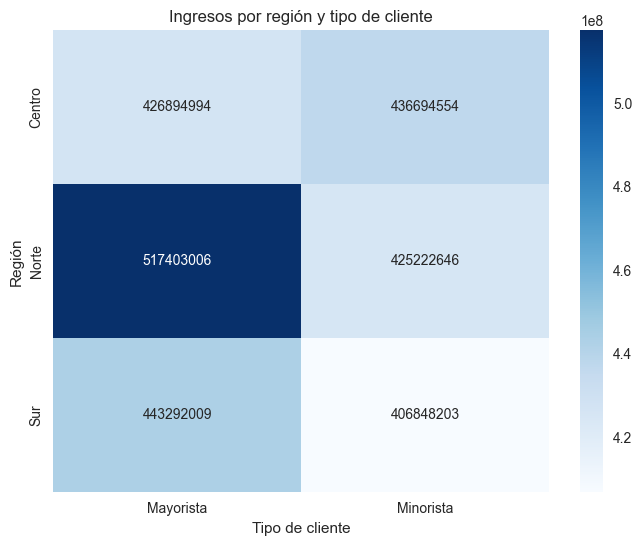

In [11]:
# Segmentaciónpor región y tipo de cliente
ventas_segmento = df.groupby(["region","tipo_cliente"])['monto_total'].sum().reset_index()

pivot_segmento = ventas_segmento.pivot(index="region", columns="tipo_cliente", values="monto_total")

plt.figure(figsize=(8,6))
sns.heatmap(pivot_segmento, annot=True, fmt=".0f", cmap="Blues")
plt.title("Ingresos por región y tipo de cliente")
plt.xlabel("Tipo de cliente")
plt.ylabel("Región")
plt.show()

**Interpretación:**
La Región Norte muestra mayores ingresos en clientes mayoristas, mientras que el Centro mantiene un equilibrio entre ambos tipos de clientes. El Sur presenta ingresos más bajos en general.

**Justificación del gráfico:**
El heatmap permite visualizar rápidamente diferencias por región y tipo de cliente gracias a la intensidad del color.

**Hallazgo clave:**
La empresa puede diseñar estrategias regionales: fortalecer la relación con mayoristas en el Norte, mantener equilibrio en el Centro y explorar oportunidades de crecimiento en el Sur.

# PARTE 3: Principios de visualización

1. **Percepción visual aplicada**
- Colores diferenciados por categoría/segmento para facilitar la lectura.
- Títulos claros en español y etiquetas legibles en ejes.
- Escalas consistentes y eliminación de elementos distractores (rejillas innecesarias, decoraciones).

2. **Evitar interpretaciones incorrectas**
- En el gráfico de barras por categoría, los valores son muy similares. Si se usara una escala truncada, podría exagerar diferencias mínimas. Se evita este problema mostrando la escala completa.
- En el scatter plot, se usan colores distintos para categorías, evitando que se interprete como una sola tendencia homogénea.
- En el heatmap, se incluyen valores numéricos además del color, para evitar confusión en la intensidad visual.

# PARTE 4: Narrativa y comunicación (Data Storytelling)

**Contexto inicial:**
Durante 2023, la empresa retail enfrentó un entorno competitivo con variaciones en la demanda a lo largo del año. La gerencia comercial busca entender cómo se comportaron las ventas, qué categorías impulsaron los ingresos y qué diferencias existen entre regiones y tipos de clientes. El objetivo es transformar los datos en decisiones estratégicas.

**Desarrollo de hallazgos clave:**
- Evolución temporal: Las ventas mostraron picos en marzo y agosto, y caídas en abril y octubre. Esto sugiere que existen factores estacionales o campañas específicas que impactan fuertemente el desempeño.
- Categorías de producto: Todas las categorías generan ingresos similares, lo que refleja una cartera diversificada. Sin embargo, la relación entre unidades vendidas y monto total revela que tecnología y electrodomésticos generan altos ingresos con menos unidades, mientras vestuario y hogar dependen de grandes volúmenes.
- Segmentación por región y cliente: El Norte con clientes mayoristas es el segmento más rentable, mientras que el Sur con minoristas muestra el menor aporte. Esto evidencia que la estrategia comercial debe adaptarse a cada región y tipo de cliente.

**Conclusión orientada a decisiones:**
Los datos muestran que la empresa tiene una base sólida y diversificada, pero existen oportunidades claras: reforzar campañas en meses de baja venta, diferenciar estrategias según categoría de producto, y potenciar la relación con mayoristas en el Norte mientras se diseñan acciones específicas para mejorar el desempeño minorista en el Sur. La narrativa apunta a que las decisiones deben ser segmentadas y oportunas, basadas en evidencia.

# PARTE 5: Conclusiones e insights


1. **Estacionalidad en ventas**
- Qué se observa: Picos en marzo y agosto, caídas en abril y octubre.
- Por qué es importante: Identifica momentos críticos de alta y baja demanda.
- Acción: Planificar campañas promocionales en meses de baja y replicar estrategias exitosas de los meses de mayor venta.

2. **Diferencias entre categorías de producto**
- Qué se observa: Tecnología y electrodomésticos generan altos ingresos con menos unidades; vestuario y hogar requieren volumen.
- Por qué es importante: Permite entender la dinámica de valor vs. volumen.
- Acción: Ajustar estrategias: premium marketing para productos de alto valor unitario y campañas masivas para categorías de volumen.

3. Segmentación regional y de clientes
- Qué se observa: Norte mayorista es el segmento más rentable; Sur minorista el menos.
- Por qué es importante: Muestra que no todas las regiones ni tipos de clientes aportan igual.
- Acción: Reforzar la relación con mayoristas en el Norte y diseñar estrategias específicas para minoristas en el Sur (ej. promociones locales, alianzas).